# ITM Basket Comparison -- Sandbox

Goal: **reduce Max DD** (accepting lower CAGR if needed) by adding ITM calls to the basket.
ITM calls cost more total premium but burn less time-value per unit of delta -- and their
delta survives moderate crashes (10-20% moves) better than any OTM leg.

All baskets: TSLA calls only, delta-neutral (each leg sized at 1/N of target dollar-delta),
rolled together when the earliest-expiring leg hits `ROLL_DTE`. Full period, frictionless.

**Compositions tested:**

| Label | Legs |
|---|---|
| Baseline | 10% OTM only (single-leg static calendar roll) |
| A | ATM + 10%OTM + 20%OTM (original basket) |
| B | 10%ITM + ATM + 10%OTM (drop 20%OTM, add ITM anchor) |
| C | 10%ITM + ATM + 10%OTM + 20%OTM (full 4-leg) |
| D | 10%ITM + 10%OTM + 20%OTM (drop ATM, ITM as high-delta anchor) |
| E | 20%ITM + 10%ITM + ATM + 10%OTM (deep ITM, drop 20%OTM) |
| F | 20%ITM + 10%ITM + ATM (pure ITM-to-ATM, no OTM) |

Sorted by Max DD (primary) then Sharpe.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll, load_tsla_calls
from options_selection import select_contract, bs_delta, MONEYNESS_RANGES
from metrics import summarize

# Extend bucket definitions locally -- no production files touched
MONEYNESS_RANGES["10% ITM"] = (0.85, 0.95)
MONEYNESS_RANGES["20% ITM"] = (0.75, 0.85)

%matplotlib inline

tsll       = load_tsll()
r_tsll     = tsll.set_index("Date")["Close"].pct_change().dropna()
returns    = r_tsll.rename("TSLL").to_frame()

tsla_spot  = load_tsla_underlying().set_index("Date")["Close"].reindex(returns.index).ffill()
tsla_calls = load_tsla_calls()
price_lut  = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

r_tsla     = tsla_spot.pct_change()
sigma_s    = (r_tsla.rolling(21).std() * (252 ** 0.5)).ffill().bfill()

print(f"{len(returns):,} trading days  {returns.index.min().date()} -> {returns.index.max().date()}")
print(f"ITM buckets registered: {[k for k in MONEYNESS_RANGES if 'ITM' in k]}")
print("Data loaded.")

962 trading days  2022-08-10 -> 2026-06-10
ITM buckets registered: ['10% ITM', '20% ITM']
Data loaded.


In [2]:
TARGET_DTE = 90
MAX_DTE    = 110
ROLL_DTE   = 5
TSLL_LEVER = 2.0
R_RF       = 0.05

# Fallback chain: if primary bucket has no fill, step toward ATM
FALLBACK = {
    "20% ITM" : ["10% ITM", "ATM"],
    "10% ITM" : ["ATM"],
    "ATM"     : ["10% OTM"],
    "10% OTM" : ["ATM"],
    "20% OTM" : ["10% OTM", "ATM"],
}

COMPOSITIONS = {
    "Baseline (10%OTM only)": ["10% OTM"],
    "A: ATM+10%OTM+20%OTM":  ["ATM", "10% OTM", "20% OTM"],
    "B: 10%ITM+ATM+10%OTM":  ["10% ITM", "ATM", "10% OTM"],
    "C: 10%ITM+ATM+10%OTM+20%OTM": ["10% ITM", "ATM", "10% OTM", "20% OTM"],
    "D: 10%ITM+10%OTM+20%OTM":     ["10% ITM", "10% OTM", "20% OTM"],
    "E: 20%ITM+10%ITM+ATM+10%OTM": ["20% ITM", "10% ITM", "ATM", "10% OTM"],
    "F: 20%ITM+10%ITM+ATM":        ["20% ITM", "10% ITM", "ATM"],
}

print(f"target_dte={TARGET_DTE}  roll_dte={ROLL_DTE}  frictionless  TSLA calls only")
print(f"{len(COMPOSITIONS)} compositions to test")

target_dte=90  roll_dte=5  frictionless  TSLA calls only
7 compositions to test


In [3]:
def _pick_contract(d, bucket):
    """Try primary bucket, then fallback chain. Returns (row, bucket_used) or (None, None)."""
    for b in [bucket] + FALLBACK.get(bucket, []):
        row = select_contract(tsla_calls, tsla_spot, d, b, TARGET_DTE, max_dte=MAX_DTE)
        if row is not None:
            return row, b
    return None, None


def simulate_basket(returns, basket_buckets):
    """
    Short $1 TSLL (fixed notional) + simultaneous basket of TSLA calls.
    Each leg sized at (1/N) of the target dollar-delta.
    All legs roll together when the earliest-expiring leg hits ROLL_DTE.
    Falls back to a closer-to-ATM bucket if primary has no fill.

    Returns (equity, n_leg_misses, n_fallbacks)
    """
    n_legs      = len(basket_buckets)
    cum_tsll    = (1 + returns["TSLL"]).cumprod()
    base_equity = 2.0 - cum_tsll

    equity      = pd.Series(index=returns.index, dtype=float)
    positions   = {b: None for b in basket_buckets}  # one slot per leg
    option_pnl  = 0.0
    n_misses    = 0
    n_fallbacks = 0

    def mtm(pos, d):
        if d > pos["expiry"]:
            return max(float(tsla_spot.loc[d]) - pos["strike"], 0.0)
        px = price_lut.get((pos["raw_id"], d))
        return float(px) if (px is not None and not pd.isna(px)) else pos["price"]

    for d in returns.index:
        # roll if ANY leg is missing OR earliest-expiring leg hits ROLL_DTE
        held_dtes  = [(positions[b]["expiry"] - d).days
                      if positions[b] is not None else -1
                      for b in basket_buckets]
        need_roll  = any(positions[b] is None for b in basket_buckets) \
                     or min(held_dtes) < ROLL_DTE

        if need_roll:
            # close all existing legs
            for b in basket_buckets:
                if positions[b] is not None:
                    option_pnl += positions[b]["n"] * 100 * (
                        mtm(positions[b], d) - positions[b]["price"])

            # open new legs
            S         = float(tsla_spot.loc[d])
            sigma     = float(sigma_s.loc[d]) if d in sigma_s.index else 0.5
            target_dd = TSLL_LEVER * float(cum_tsll.loc[d]) / n_legs  # per-leg dollar-delta target

            new_positions = {}
            for b in basket_buckets:
                row, b_used = _pick_contract(d, b)
                if row is not None:
                    if b_used != b:
                        n_fallbacks += 1
                    T     = (row["expiry"] - d).days / 365.25
                    delta = bs_delta(S, float(row["strike"]), T, R_RF, sigma)
                    n     = target_dd / (max(delta, 0.01) * 100 * S)
                    new_positions[b] = {"raw_id": row["raw_id"],
                                        "strike": float(row["strike"]),
                                        "expiry": row["expiry"],
                                        "n": n,
                                        "price": float(row["px_last"])}
                else:
                    new_positions[b] = None
                    n_misses += 1
            positions = new_positions

        else:
            # hold: mark all legs to market
            for b in basket_buckets:
                if positions[b] is not None:
                    px = mtm(positions[b], d)
                    option_pnl        += positions[b]["n"] * 100 * (px - positions[b]["price"])
                    positions[b]["price"] = px

        equity.loc[d] = base_equity.loc[d] + option_pnl

    return equity, n_misses, n_fallbacks

In [4]:
rows   = []
curves = {}

for label, buckets in COMPOSITIONS.items():
    eq, n_miss, n_fb = simulate_basket(returns, buckets)
    eq = eq / eq.iloc[0]
    assert eq.isna().sum() == 0, f"{label}: NaNs in equity"
    curves[label] = eq
    row = summarize(eq, eq.pct_change().dropna(), label)
    row["Leg misses"]  = n_miss
    row["Fallbacks"]   = n_fb
    rows.append(row)
    print(f"{label:42s}  CAGR={row['CAGR']:+.1%}  Sharpe={row['Sharpe']:.2f}  MaxDD={row['Max DD']:.1%}")

results_df = pd.DataFrame(rows).sort_values("Max DD", ascending=False)  # least-negative = best
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)
print()
print("=== Ranked by Max DD (best first) ===")
print(results_df[["Strategy", "CAGR", "Ann. Vol", "Sharpe", "Max DD",
                  "Calmar", "Leg misses", "Fallbacks"]].to_string(index=False))

Baseline (10%OTM only)                      CAGR=-36.0%  Sharpe=-0.67  MaxDD=-90.7%


A: ATM+10%OTM+20%OTM                        CAGR=-30.4%  Sharpe=-0.63  MaxDD=-85.6%


B: 10%ITM+ATM+10%OTM                        CAGR=+7.8%  Sharpe=0.41  MaxDD=-39.2%
C: 10%ITM+ATM+10%OTM+20%OTM                 CAGR=+9.7%  Sharpe=0.47  MaxDD=-34.9%


D: 10%ITM+10%OTM+20%OTM                     CAGR=+7.5%  Sharpe=0.39  MaxDD=-40.3%
E: 20%ITM+10%ITM+ATM+10%OTM                 CAGR=+6.5%  Sharpe=0.37  MaxDD=-35.6%
F: 20%ITM+10%ITM+ATM                        CAGR=+5.6%  Sharpe=0.33  MaxDD=-36.5%

=== Ranked by Max DD (best first) ===
                   Strategy      CAGR  Ann. Vol    Sharpe    Max DD    Calmar  Leg misses  Fallbacks
C: 10%ITM+ATM+10%OTM+20%OTM  0.097026  0.282474  0.469736 -0.348977  0.278031           0          4
E: 20%ITM+10%ITM+ATM+10%OTM  0.064663  0.256674  0.371944 -0.355779  0.181750           0          2
       F: 20%ITM+10%ITM+ATM  0.056464  0.281062  0.334936 -0.365108  0.154649           0          2
       B: 10%ITM+ATM+10%OTM  0.077637  0.276133  0.408575 -0.391820  0.198146           0          1
    D: 10%ITM+10%OTM+20%OTM  0.074787  0.318230  0.385969 -0.403307  0.185433           0          4
       A: ATM+10%OTM+20%OTM -0.304350  0.433361 -0.625274 -0.855647 -0.355696           0          3
     Bas

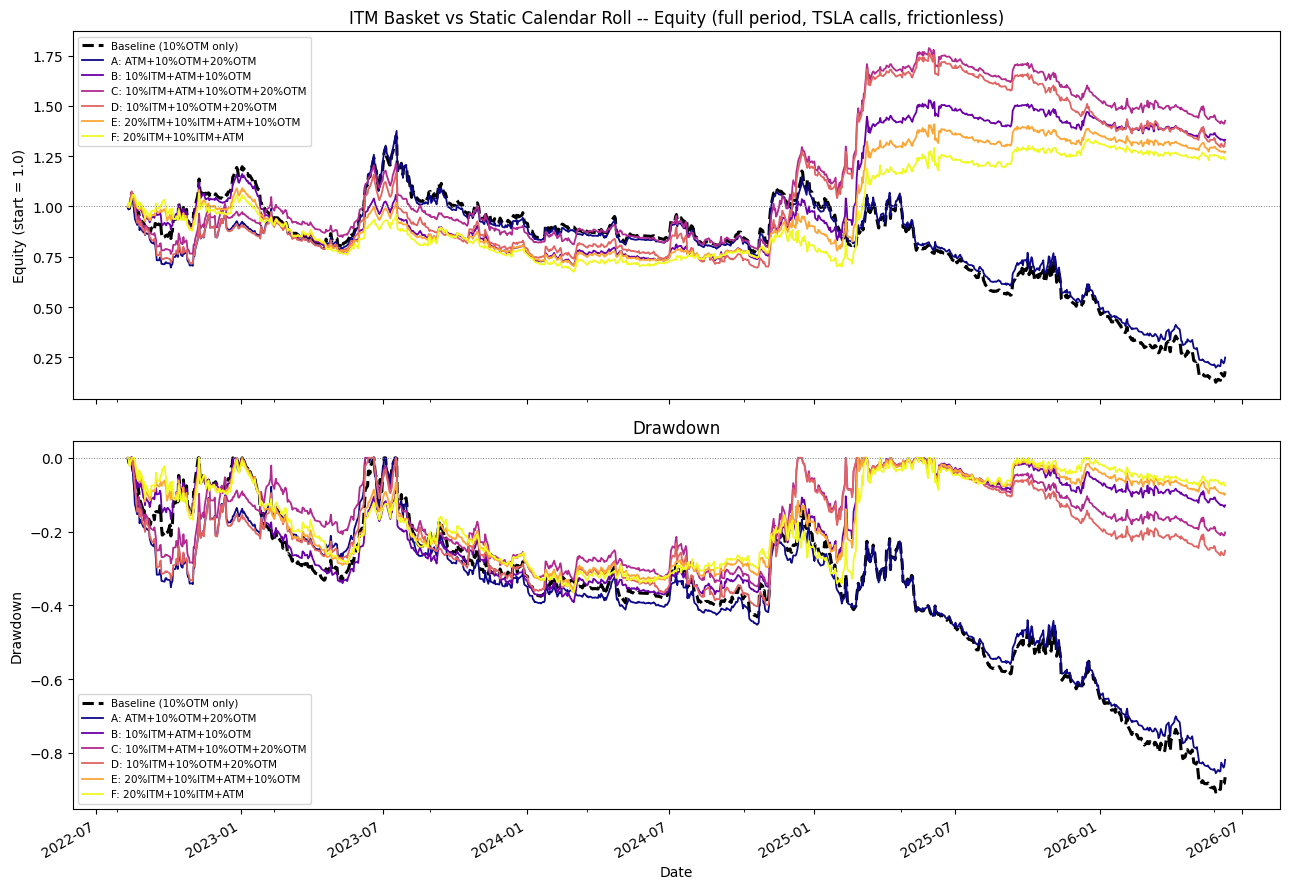

Saved: observations/strategies/sandbox/itm_basket_comparison.png

Final ranked table (Max DD best first):
                   Strategy      CAGR    Sharpe    Max DD    Calmar  Fallbacks
C: 10%ITM+ATM+10%OTM+20%OTM  0.097026  0.469736 -0.348977  0.278031          4
E: 20%ITM+10%ITM+ATM+10%OTM  0.064663  0.371944 -0.355779  0.181750          2
       F: 20%ITM+10%ITM+ATM  0.056464  0.334936 -0.365108  0.154649          2
       B: 10%ITM+ATM+10%OTM  0.077637  0.408575 -0.391820  0.198146          1
    D: 10%ITM+10%OTM+20%OTM  0.074787  0.385969 -0.403307  0.185433          4
       A: ATM+10%OTM+20%OTM -0.304350 -0.625274 -0.855647 -0.355696          3
     Baseline (10%OTM only) -0.360328 -0.668255 -0.906625 -0.397439          0


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# baseline gets its own distinct style; others get a colormap
non_baseline = [l for l in curves if "Baseline" not in l]
colors = cm.plasma([i / max(len(non_baseline)-1, 1) for i in range(len(non_baseline))])

# draw baseline first (thick dashed grey)
bl_label = "Baseline (10%OTM only)"
curves[bl_label].plot(ax=axes[0], label=bl_label, color="black", linewidth=2.2, linestyle="--")
(curves[bl_label] / curves[bl_label].cummax() - 1).plot(
    ax=axes[1], label=bl_label, color="black", linewidth=2.2, linestyle="--")

for (label, color) in zip(non_baseline, colors):
    curves[label].plot(ax=axes[0], label=label, color=color, linewidth=1.3)
    (curves[label] / curves[label].cummax() - 1).plot(
        ax=axes[1], label=label, color=color, linewidth=1.3)

axes[0].axhline(1.0, color="grey", linestyle=":", linewidth=0.7)
axes[0].set_title("ITM Basket vs Static Calendar Roll -- Equity (full period, TSLA calls, frictionless)")
axes[0].set_ylabel("Equity (start = 1.0)")
axes[0].legend(fontsize=7.5, loc="upper left")

axes[1].axhline(0.0, color="grey", linestyle=":", linewidth=0.7)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].legend(fontsize=7.5, loc="lower left")

fig.tight_layout()
out = ROOT / "observations" / "strategies" / "sandbox" / "itm_basket_comparison.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")
print()
print("Final ranked table (Max DD best first):")
print(results_df[["Strategy", "CAGR", "Sharpe", "Max DD", "Calmar", "Fallbacks"]].to_string(index=False))